# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [8]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [9]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [11]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [12]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [13]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [16]:
print("=== LabelEncoder: asigna un entero a cada categoría ===")
print(data[['sex', 'sex_label']].drop_duplicates().sort_values('sex_label'))

print("\n=== OneHotEncoder: crea una columna binaria por categoría ===")
print(data[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].drop_duplicates().dropna().sort_values('embarked'))

print("""
Diferencias clave:
- LabelEncoder: genera un único número entero (0, 1, 2...). 
  Puede introducir un orden artificial entre categorías.
- OneHotEncoder: crea una columna por categoría (0 o 1). 
  No implica orden y es más adecuado para variables nominales.
""")


=== LabelEncoder: asigna un entero a cada categoría ===
      sex  sex_label
1  female          0
0    male          1

=== OneHotEncoder: crea una columna binaria por categoría ===
  embarked  embarked_C  embarked_Q  embarked_S
1        C        True       False       False
5        Q       False        True       False
0        S       False       False        True

Diferencias clave:
- LabelEncoder: genera un único número entero (0, 1, 2...). 
  Puede introducir un orden artificial entre categorías.
- OneHotEncoder: crea una columna por categoría (0 o 1). 
  No implica orden y es más adecuado para variables nominales.



### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

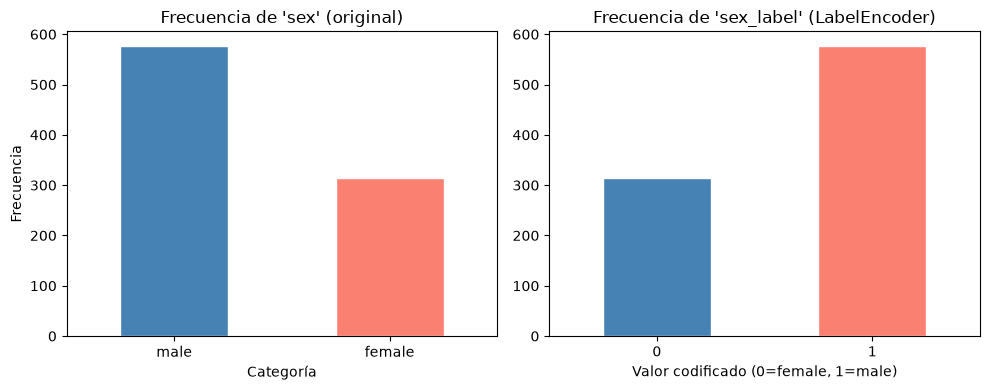

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Antes: frecuencia de categorías originales
data['sex'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title("Frecuencia de 'sex' (original)")
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(rotation=0)

# Después: frecuencia de valores codificados
data['sex_label'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='white')
axes[1].set_title("Frecuencia de 'sex_label' (LabelEncoder)")
axes[1].set_xlabel('Valor codificado (0=female, 1=male)')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()


### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [20]:
class_onehot = pd.get_dummies(data['class'], prefix='class')
print("OneHotEncoder aplicado a 'class':")
print(pd.concat([data['class'], class_onehot], axis=1).drop_duplicates().sort_values('class'))

print("""
Ventajas de OneHotEncoder frente a LabelEncoder para 'class':
- 'class' tiene categorías nominales sin orden real (First, Second, Third).
- LabelEncoder asignaría 0, 1, 2 implicando que Third > Second > First,
  lo que podría confundir al modelo.
- OneHotEncoder representa cada clase de forma independiente y equitativa,
  sin introducir relaciones de orden falsas.
""")


OneHotEncoder aplicado a 'class':
    class  class_First  class_Second  class_Third
1   First         True         False        False
9  Second        False          True        False
0   Third        False         False         True

Ventajas de OneHotEncoder frente a LabelEncoder para 'class':
- 'class' tiene categorías nominales sin orden real (First, Second, Third).
- LabelEncoder asignaría 0, 1, 2 implicando que Third > Second > First,
  lo que podría confundir al modelo.
- OneHotEncoder representa cada clase de forma independiente y equitativa,
  sin introducir relaciones de orden falsas.



### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [21]:
print("""
Para un modelo de aprendizaje automático usaría:

1. OneHotEncoder para variables nominales (sin orden):
   - 'sex', 'embarked', 'class'
   - Evita que el modelo interprete un orden inexistente entre categorías.
   - Ideal para modelos lineales, SVM, redes neuronales.

2. LabelEncoder (u OrdinalEncoder) solo para variables ordinales (con orden real):
   - Por ejemplo: nivel educativo (bajo < medio < alto).
   - Árboles de decisión y modelos basados en árboles (Random Forest, XGBoost)
     pueden manejar LabelEncoder incluso en nominales, ya que aprenden 
     particiones en lugar de magnitudes.

Conclusión: OneHotEncoder es la opción más segura y general para variables 
nominales en la mayoría de los algoritmos.
""")



Para un modelo de aprendizaje automático usaría:

1. OneHotEncoder para variables nominales (sin orden):
   - 'sex', 'embarked', 'class'
   - Evita que el modelo interprete un orden inexistente entre categorías.
   - Ideal para modelos lineales, SVM, redes neuronales.

2. LabelEncoder (u OrdinalEncoder) solo para variables ordinales (con orden real):
   - Por ejemplo: nivel educativo (bajo < medio < alto).
   - Árboles de decisión y modelos basados en árboles (Random Forest, XGBoost)
     pueden manejar LabelEncoder incluso en nominales, ya que aprenden 
     particiones en lugar de magnitudes.

Conclusión: OneHotEncoder es la opción más segura y general para variables 
nominales en la mayoría de los algoritmos.

